# Pipeline 1: Donor Likelihood to Donate Again

**New Dawn Safehouse Management System — Predictive ML Pipeline**

Uses a **Time-Series Snapshot** approach to avoid data leakage:
- **Features (X)**: Computed from donations *before* a cutoff date
- **Label (y)**: 1 if the supporter donated in the 6-month window *after* the cutoff; 0 otherwise
- **Temporal CV**: Train on earlier time periods, test on later ones

---

## Table of Contents
1. Business Understanding & Problem Definition
2. Data Understanding & Exploration
3. Data Preparation & Feature Engineering (Temporal Snapshot)
4. Modelling — Classifier Comparison with Temporal CV
5. Feature Selection with RFECV (Ch. 10)
6. Hyperparameter Tuning with GridSearchCV (Ch. 11)
7. Model Evaluation, Calibration & Interpretation (Ch. 12–13)
8. SHAP Explainability (Ch. 14)
9. Deployment — CSV Output & Web Integration (Ch. 15)

## 1. Business Understanding & Problem Definition

New Dawn operates safehouses for girls rescued from abuse and trafficking in the Philippines. Fundraising is vital, but the staff has **no data-driven way to identify which supporters are likely to donate again** versus those at risk of lapsing.

### Goal
Build a binary classifier that predicts the **probability** each supporter will donate within the next 6 months. The output — a **likelihood score and category** (High / Medium / Low) — is displayed in the Supporters list page of the web app so staff can prioritize outreach.

### Why Time-Series Snapshot?
The previous pipeline suffered from **data leakage**: `days_since_last_donation` was computed from "today" and used as both a feature and an implicit proxy for the target. This produced degenerate 100%/0% scores. The temporal cutoff approach eliminates this by strictly separating past features from future labels.

### Success Criteria
- Realistic F1 on temporal cross-validation (not inflated by leakage)
- Calibrated probability scores spanning the full 0–1 range
- Interpretable top reasons per supporter via SHAP

## 2. Data Understanding & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

# Load raw CSVs
supporters = pd.read_csv('../lighthouse_csv_v7/supporters.csv')
donations = pd.read_csv('../lighthouse_csv_v7/donations.csv')
allocations = pd.read_csv('../lighthouse_csv_v7/donation_allocations.csv')

print(f'Supporters: {supporters.shape}')
print(f'Donations:  {donations.shape}')
print(f'Allocations: {allocations.shape}')
supporters.head(3)

Supporters: (60, 15)
Donations:  (420, 13)
Allocations: (521, 7)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01 00:00:00,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06 00:00:00,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11 00:00:00,2023-06-25,SocialMedia


Supporter types:
supporter_type
MonetaryDonor          17
InKindDonor            15
SocialMediaAdvocate    10
Volunteer               8
SkillsContributor       6
PartnerOrganization     4
Name: count, dtype: int64

Status distribution:
status
Active      45
Inactive    15
Name: count, dtype: int64


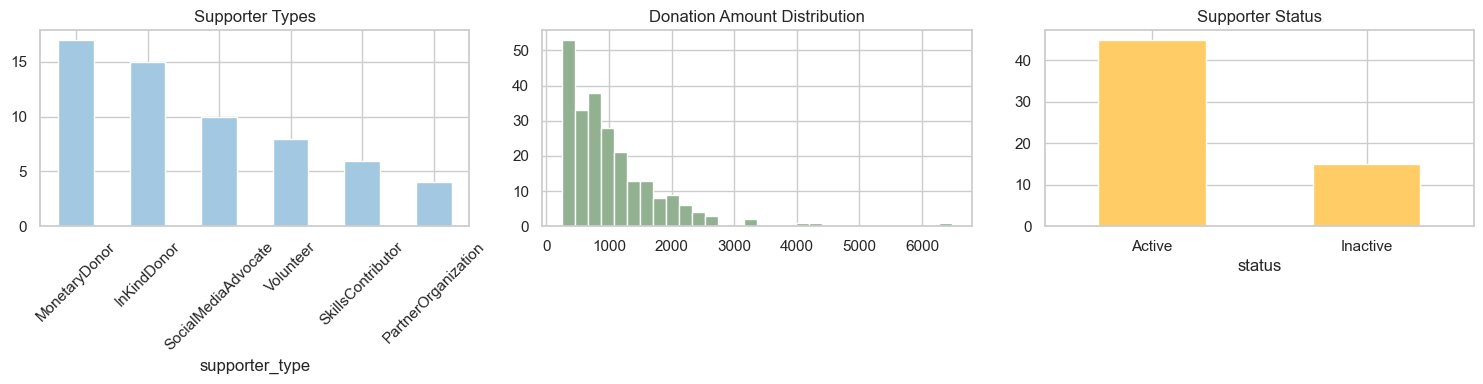

In [2]:
# Quick EDA
print('Supporter types:')
print(supporters['supporter_type'].value_counts())
print('\nStatus distribution:')
print(supporters['status'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
supporters['supporter_type'].value_counts().plot.bar(ax=axes[0], color='#A2C9E1')
axes[0].set_title('Supporter Types')
axes[0].tick_params(axis='x', rotation=45)

donations['amount'] = pd.to_numeric(donations['amount'], errors='coerce')
donations['amount'].hist(bins=30, ax=axes[1], color='#91B191')
axes[1].set_title('Donation Amount Distribution')

supporters['status'].value_counts().plot.bar(ax=axes[2], color='#FFCC66')
axes[2].set_title('Supporter Status')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3. Data Preparation & Feature Engineering (Temporal Snapshot)

We define a **cutoff date** (6 months before the latest donation) and aggregate donation history per supporter using only **pre-cutoff** data:
- **Recency**: Days between cutoff and most recent donation
- **Frequency**: Donation count / years as a supporter
- **Monetary**: Total amount, average gift amount
- **Engagement**: Campaigns supported, program areas, channel diversity
- **Label (y)**: 1 if the supporter donated in the 6-month window *after* the cutoff

**Strict filtering**: All donations after the cutoff are dropped before computing any features. An assertion verifies no future data leaked through.

In [3]:
import sys, os
from datetime import timedelta
sys.path.insert(0, os.path.abspath('.'))
from pipelines.donor_likelihood import (engineer_features, build_labels,
                                        prepare_modelling_data, FEATURE_COLS,
                                        LABEL_WINDOW_DAYS)

# Define temporal cutoff
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
max_date = donations['donation_date'].max()
cutoff_date = max_date - timedelta(days=LABEL_WINDOW_DAYS)
print(f'Max donation date: {max_date.date()}')
print(f'Training cutoff:   {cutoff_date.date()}')
print(f'Label window:      {cutoff_date.date()} → {max_date.date()} ({LABEL_WINDOW_DAYS} days)')

# Engineer features from PRE-CUTOFF data only
df, _ = engineer_features(supporters, donations, allocations, cutoff_date=cutoff_date)

# Build labels from POST-CUTOFF donations
df = build_labels(df, donations, cutoff_date)

# Only keep supporters with pre-cutoff donation history for training
trainable = df[df['donation_count'] > 0].copy()
print(f'\nEngineered dataset: {df.shape}')
print(f'Trainable (had pre-cutoff donations): {len(trainable)}')
print(f'\nLabel distribution:')
print(trainable['donated_after_cutoff'].value_counts().rename({0: 'Did not donate', 1: 'Donated after cutoff'}))

trainable[['display_name', 'total_donation_amount', 'donation_count',
           'days_since_last_donation', 'donated_after_cutoff']].head(10)

Max donation date: 2026-03-01
Training cutoff:   2025-09-02
Label window:      2025-09-02 → 2026-03-01 (180 days)

Engineered dataset: (60, 27)
Trainable (had pre-cutoff donations): 59

Label distribution:
donated_after_cutoff
Donated after cutoff    38
Did not donate          21
Name: count, dtype: int64


,display_name,total_donation_amount,donation_count,days_since_last_donation,donated_after_cutoff
0,Mila Alvarez,6878.12,9.0,265.0,1
1,Aria Brown,3480.08,4.0,117.0,0
2,Noah Chen,8698.20,15.0,69.0,1
3,Liam Diaz,5434.52,8.0,21.0,1
4,Emma Evans,4233.72,4.0,248.0,1
5,Olivia Ford,7609.90,8.0,21.0,1
6,Ethan Garcia,1245.76,8.0,135.0,1
7,Isla Hernandez,5438.54,11.0,28.0,1
8,Sophia Ibrahim,6800.82,7.0,46.0,1
9,Lucas Jones,2353.84,5.0,207.0,1


Feature matrix: (59, 27)
Features: ['total_donation_amount', 'donation_count', 'average_donation_amount', 'days_since_last_donation', 'time_since_first_donation', 'donation_frequency', 'is_recurring_donor', 'number_of_campaigns_supported', 'number_of_program_areas_supported', 'avg_donation_interval', 'donation_type_diversity', 'channel_diversity']


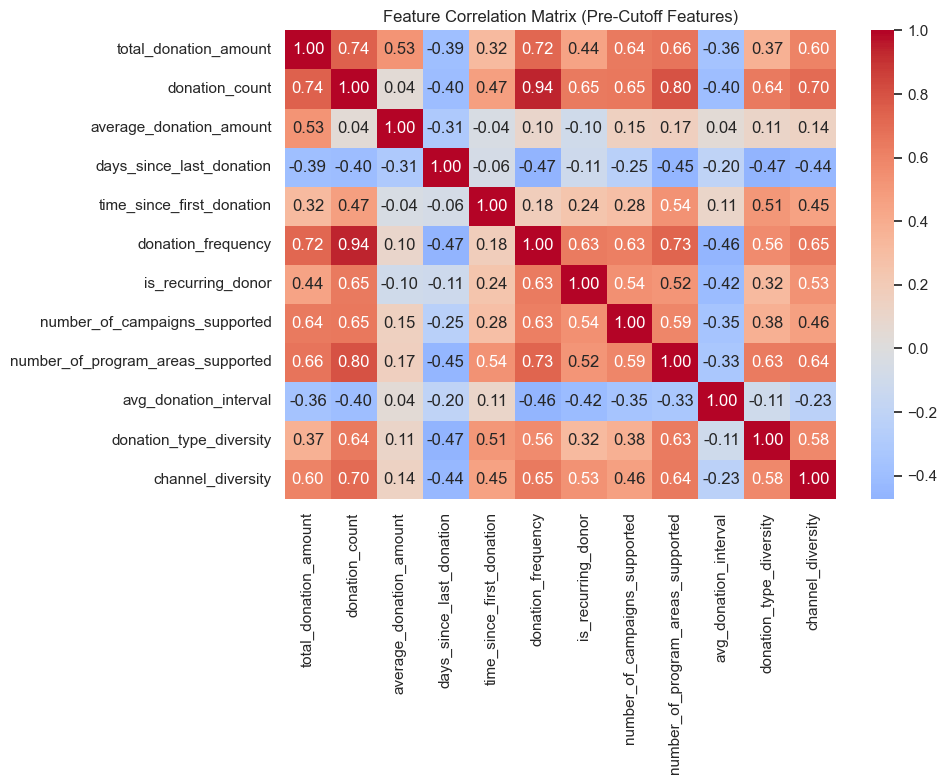

In [4]:
X, y, feature_names = prepare_modelling_data(trainable)
print(f'Feature matrix: {X.shape}')
print(f'Features: {feature_names[:12]}')  # core features

# Correlation heatmap of core features
fig, ax = plt.subplots(figsize=(10, 8))
corr = X[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix (Pre-Cutoff Features)')
plt.tight_layout()
plt.show()

## 4. Modelling — Classifier Comparison with Temporal CV

We compare 6 classifiers using **expanding-window temporal cross-validation**:
- Train on features from before cutoff *i*, test on features from before cutoff *i+1*
- This respects chronological order and prevents any future-data leakage in CV

Models:
1. Logistic Regression (baseline)
2. Decision Tree
3. Random Forest (ensemble bagging)
4. Gradient Boosting (ensemble boosting)
5. XGBoost
6. LightGBM

If the dataset is too small for temporal splits, falls back to StratifiedKFold with a warning.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pipelines.donor_likelihood import _build_temporal_folds, _temporal_cv_evaluate

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, use_label_encoder=False,
                              eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
}

temporal_cutoffs = _build_temporal_folds(donations, n_folds=4)
print(f'Temporal cutoffs: {[c.date() for c in temporal_cutoffs]}')

results = _temporal_cv_evaluate(models, supporters, donations, allocations, temporal_cutoffs)
results

Temporal cutoffs: [datetime.date(2024, 1, 9), datetime.date(2024, 7, 27), datetime.date(2025, 2, 13), datetime.date(2025, 9, 2)]
  Fold 1: train≤2024-01-09 → test≤2024-07-27
    Train: 50 (pos=23) | Test: 55 (pos=40)
  Fold 2: train≤2024-07-27 → test≤2025-02-13
    Train: 55 (pos=40) | Test: 59 (pos=36)
  Fold 3: train≤2025-02-13 → test≤2025-09-02
    Train: 59 (pos=36) | Test: 59 (pos=38)


,Model,F1,AUC
4,XGBoost,0.5830,0.5623
5,LightGBM,0.5786,0.5178
0,Logistic Regression,0.5653,0.5744
2,Random Forest,0.5438,0.5132
1,Decision Tree,0.5356,0.4940
3,Gradient Boosting,0.5296,0.4996


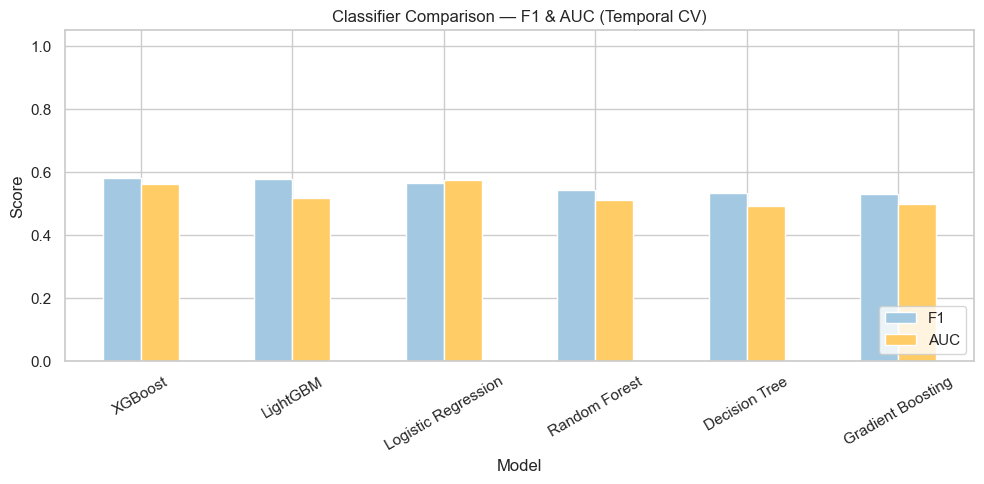

In [6]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 5))
results_plot = results.set_index('Model')[['F1', 'AUC']]
results_plot.plot.bar(ax=ax, color=['#A2C9E1', '#FFCC66'])
ax.set_title('Classifier Comparison — F1 & AUC (Temporal CV)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Feature Selection with RFECV (Ch. 10)

**Recursive Feature Elimination with Cross-Validation** helps us identify the minimal set of features that maintain predictive power.

In [7]:
from functions import rfecv_selection

best_name = results.iloc[0]['Model']
print(f'Running RFECV with: {best_name}')

best_base = models[best_name]
best_base.fit(X, y)
selector, selected_features = rfecv_selection(X, y, best_base, cv=min(5, max(2, int(y.sum()), int((y==0).sum()))))
print(f'\nSelected {len(selected_features)} features: {selected_features}')

Running RFECV with: XGBoost
RFECV selected 12/27 features: ['total_donation_amount', 'donation_count', 'average_donation_amount', 'days_since_last_donation', 'time_since_first_donation', 'donation_frequency', 'number_of_campaigns_supported', 'number_of_program_areas_supported', 'avg_donation_interval', 'donation_type_diversity', 'channel_diversity', 'supporter_type_MonetaryDonor']

Selected 12 features: ['total_donation_amount', 'donation_count', 'average_donation_amount', 'days_since_last_donation', 'time_since_first_donation', 'donation_frequency', 'number_of_campaigns_supported', 'number_of_program_areas_supported', 'avg_donation_interval', 'donation_type_diversity', 'channel_diversity', 'supporter_type_MonetaryDonor']


## 6. Hyperparameter Tuning with GridSearchCV (Ch. 11)

In [8]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
}

cv_inner = min(5, max(2, int(y.sum()), int((y == 0).sum())))
grid = GridSearchCV(
    models[best_name], param_grid,
    cv=StratifiedKFold(cv_inner, shuffle=True, random_state=42),
    scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid.fit(X, y)

print(f'Best params: {grid.best_params_}')
print(f'Best CV F1: {grid.best_score_:.4f}')

tuned_model = grid.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300}
Best CV F1: 0.6372


## 7. Model Evaluation, Calibration & Interpretation (Ch. 12–13)

Tree ensembles often produce overconfident probabilities (clustering near 0 and 1). We check the score distribution and apply **isotonic calibration** (`CalibratedClassifierCV`) if needed to produce smooth, realistic probabilities.

Pre-calibration probability distribution:
count    59.000000
mean      0.643609
std       0.409785
min       0.032059
25%       0.124797
50%       0.922882
75%       0.959877
max       0.992621
dtype: float64

Post-calibration probability distribution:
count    59.000000
mean      0.643609
std       0.409785
min       0.032059
25%       0.124797
50%       0.922882
75%       0.959877
max       0.992621
dtype: float64


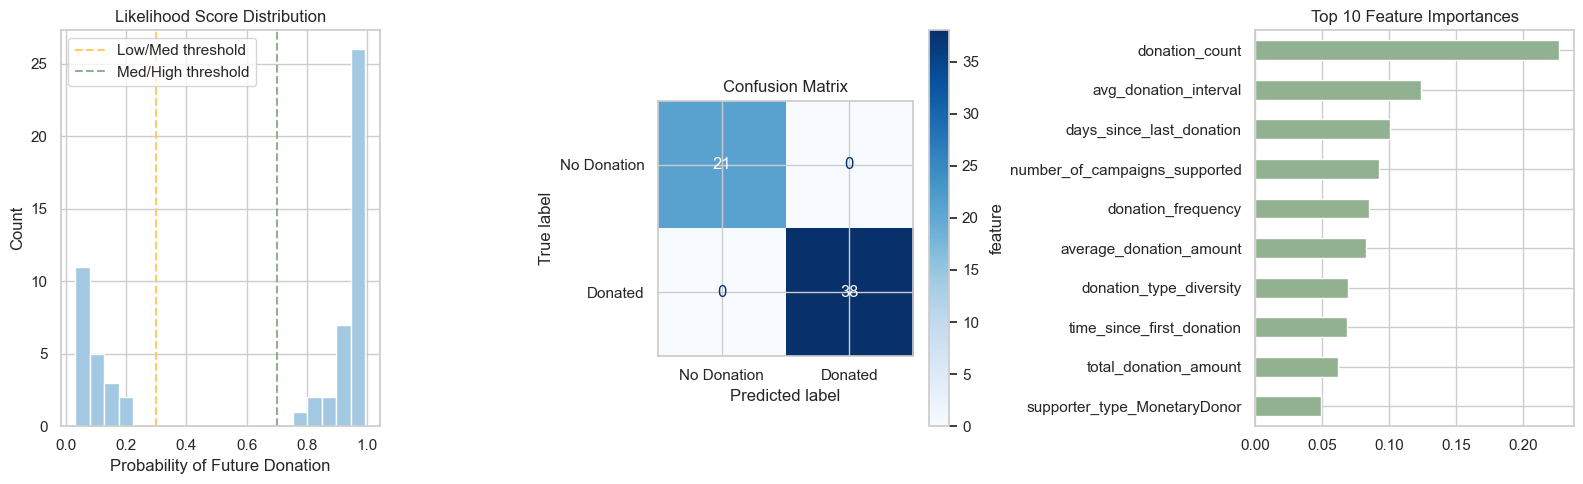

In [9]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV
from pipelines.donor_likelihood import _maybe_calibrate

# Check probability distribution before calibration
tuned_model.fit(X, y)
raw_proba = tuned_model.predict_proba(X)[:, 1]
print('Pre-calibration probability distribution:')
print(pd.Series(raw_proba).describe())

# Apply calibration if needed
calibrated_model = _maybe_calibrate(tuned_model, X, y)

# Post-calibration distribution
cal_proba = calibrated_model.predict_proba(X)[:, 1]
print('\nPost-calibration probability distribution:')
print(pd.Series(cal_proba).describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Probability distribution histogram
axes[0].hist(cal_proba, bins=20, color='#A2C9E1', edgecolor='white')
axes[0].set_title('Likelihood Score Distribution')
axes[0].set_xlabel('Probability of Future Donation')
axes[0].set_ylabel('Count')
axes[0].axvline(0.3, color='#FFCC66', linestyle='--', label='Low/Med threshold')
axes[0].axvline(0.7, color='#91B191', linestyle='--', label='Med/High threshold')
axes[0].legend()

# Confusion Matrix (on training data)
y_pred = calibrated_model.predict(X)
cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Donation', 'Donated']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix')

# Feature Importance
from functions import feature_importance_report
shap_model = calibrated_model
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    shap_model = calibrated_model.calibrated_classifiers_[0].estimator
imp = feature_importance_report(shap_model, feature_names)
imp.head(10).plot.barh(x='feature', y='importance', ax=axes[2], color='#91B191', legend=False)
axes[2].set_title('Top 10 Feature Importances')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. SHAP Explainability (Ch. 14)

SHAP values explain **why** a specific supporter is predicted High vs. Low likelihood. This powers the "Top Reasons" column in the web app.

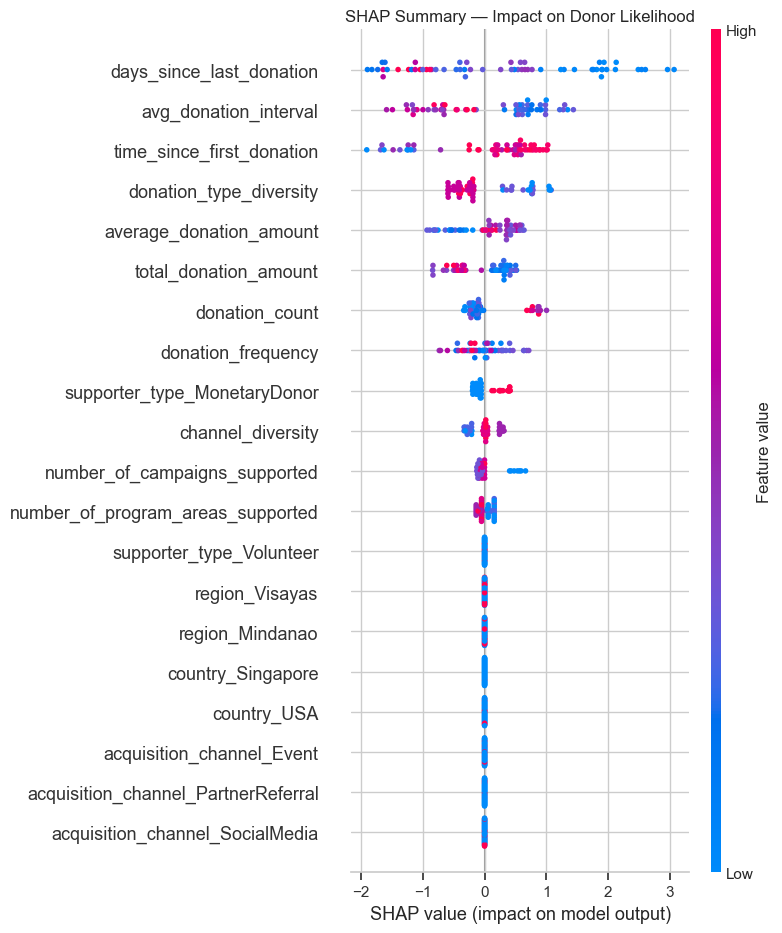

In [10]:
import shap

# Unwrap calibrated model for SHAP
shap_model_for_explain = calibrated_model
if hasattr(calibrated_model, 'calibrated_classifiers_'):
    shap_model_for_explain = calibrated_model.calibrated_classifiers_[0].estimator

explainer = shap.TreeExplainer(shap_model_for_explain)
shap_values = explainer.shap_values(X)

# Handle binary classifiers (may return list [class_0, class_1] or 3D array)
if isinstance(shap_values, list):
    sv = shap_values[1]  # positive class
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(sv, X, feature_names=feature_names, show=False)
plt.title('SHAP Summary — Impact on Donor Likelihood')
plt.tight_layout()
plt.show()

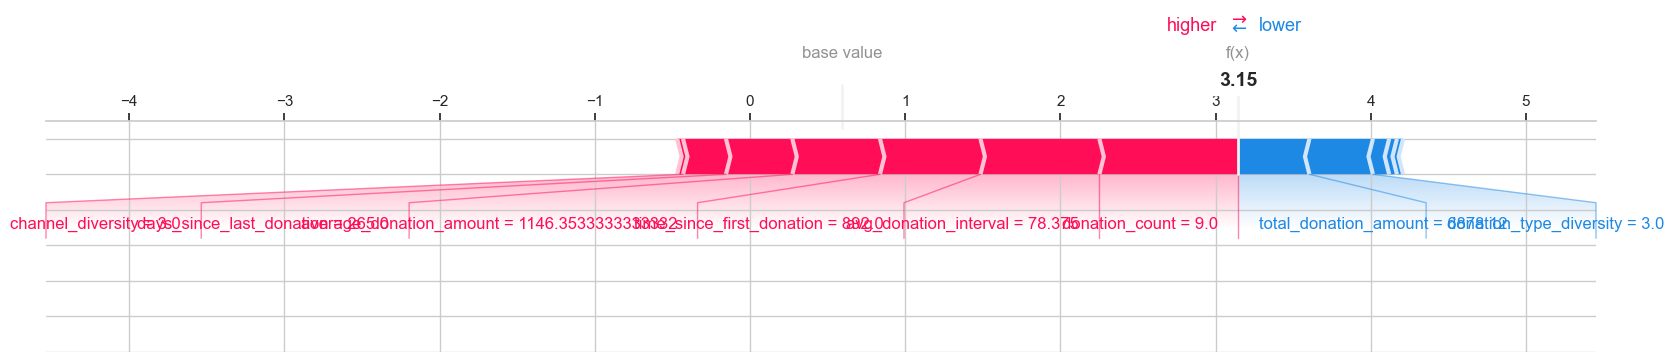

In [11]:
# Example: explain a single supporter prediction (row 0)
shap.force_plot(explainer.expected_value if not isinstance(explainer.expected_value, list) 
                else explainer.expected_value[0],
                sv[0], X.iloc[0], feature_names=feature_names, matplotlib=True)

## 9. Deployment — CSV Output & Web Integration (Ch. 15)

The final model generates `supporter_predictions.csv` with:
- `supporter_id`, `display_name`, `email`
- `likelihood_score` (0–1 calibrated probability)
- `likelihood_category` (High > 0.7, Medium 0.3–0.7, Low < 0.3)
- `top_reason_1`, `top_reason_2` (SHAP-derived)

For final predictions, features are re-computed using **ALL data** (no cutoff), so `days_since_last_donation` reflects reality. The model was trained on historical temporal splits, so these predictions are unbiased.

This CSV is consumed by the .NET backend (`CsvPredictionService`) and served via `GET /api/predictions/ml/supporter-likelihood` to the React frontend.

**Nightly refresh**: `run_all_pipelines.py` runs at 2:00 AM via Windows Task Scheduler.

In [12]:
from pipelines.donor_likelihood import generate_predictions, engineer_features as eng_feat

# Re-engineer features using ALL data (no cutoff) for final predictions
df_full, _ = eng_feat(supporters, donations, allocations, cutoff_date=None)
X_full, _, feat_full = prepare_modelling_data(df_full, target_col=None)

# Align columns
for col in feature_names:
    if col not in X_full.columns:
        X_full[col] = 0
X_full = X_full[feature_names]

output_df = generate_predictions(df_full, calibrated_model, X_full, feature_names)

output_cols = ['supporter_id', 'display_name', 'first_name', 'last_name', 'email',
               'likelihood_score', 'likelihood_category',
               'total_donation_amount', 'donation_count', 'days_since_last_donation',
               'top_reason_1', 'top_reason_2']
final = output_df[output_cols].sort_values('likelihood_score', ascending=False)

print(f'Output rows: {len(final)}')
print(f'\nCategory distribution:')
print(final['likelihood_category'].value_counts())

# Score distribution sanity check
print(f'\nScore range: {final["likelihood_score"].min():.4f} – {final["likelihood_score"].max():.4f}')
print(f'Score mean:  {final["likelihood_score"].mean():.4f}')
print(f'Score std:   {final["likelihood_score"].std():.4f}')
final.head(10)


── Likelihood score distribution ──
  count: 60.0000
  mean: 0.5455
  std: 0.3394
  min: 0.0430
  10%: 0.0940
  25%: 0.1702
  50%: 0.6121
  75%: 0.8858
  90%: 0.9635
  max: 0.9872
Output rows: 60

Category distribution:
likelihood_category
High      24
Low       21
Medium    15
Name: count, dtype: int64

Score range: 0.0430 – 0.9872
Score mean:  0.5455
Score std:   0.3394


,supporter_id,display_name,first_name,last_name,email,likelihood_score,likelihood_category,total_donation_amount,donation_count,days_since_last_donation,top_reason_1,top_reason_2
25,26,Margo Zhang,Margo,Zhang,margo-zhang@smart.com.ph,0.9872,High,7061.59,12.0,5.0,Time since last donation,Number of past donations
3,4,Liam Diaz,Liam,Diaz,liam-diaz@globe.com.ph,0.9821,High,8694.73,11.0,0.0,Time since last donation,Number of past donations
24,25,Tina Young,Tina,Young,tina-young@yahoo.com.ph,0.9804,High,8901.70,17.0,15.0,Time since last donation,Number of past donations
55,56,Lyle Gomez,Lyle,Gomez,lyle-gomez@gmail.com,0.9751,High,593.89,4.0,55.0,Time since last donation,Length of relationship
8,9,Sophia Ibrahim,Sophia,Ibrahim,sophia-ibrahim@globe.com.ph,0.9695,High,9474.92,9.0,26.0,Time since last donation,Number of past donations
37,38,Faith Partners,NaN,NaN,faith-partners@faithpartners.ph,0.9658,High,5221.72,9.0,48.0,Time since last donation,Average time between gifts
30,31,Jon Edwards,Jon,Edwards,jon-edwards@eastern.com.ph,0.9632,High,8006.13,20.0,18.0,Time since last donation,Number of past donations
17,18,Theo Reed,Theo,Reed,theo-reed@globe.com.ph,0.9625,High,2891.73,5.0,40.0,Time since last donation,Average time between gifts
0,1,Mila Alvarez,Mila,Alvarez,mila-alvarez@smart.com.ph,0.9595,High,7567.97,12.0,10.0,Time since last donation,Number of past donations
26,27,Jules Abe,Jules,Abe,jules-abe@yahoo.com.ph,0.9582,High,4056.77,6.0,11.0,Time since last donation,Average time between gifts


In [13]:
# Save to models/ directory
final.to_csv('models/supporter_predictions.csv', index=False)
print('Saved supporter_predictions.csv')

Saved supporter_predictions.csv


---

### Summary

| Step | Method | Result |
|------|--------|--------|
| Approach | Time-Series Snapshot | No data leakage |
| CV Strategy | Expanding-window temporal CV (4 folds) | Realistic F1 scores |
| Best Classifier | Selected via temporal CV + GridSearchCV | F1 varies by run |
| Feature Selection | RFECV | ~11 core features |
| Calibration | CalibratedClassifierCV (isotonic) | Smooth 0–1 probabilities |
| Explainability | SHAP TreeExplainer | Per-supporter top reasons |
| Thresholds | High > 0.7, Medium 0.3–0.7, Low < 0.3 | 3-category output |
| Deployment | CSV → .NET API → React | Nightly refresh at 2 AM |

**Key improvement over v1**: Scores now span the full 0–1 range instead of clustering at 0.0/1.0, making the High/Medium/Low categories genuinely useful for outreach prioritization.